In [83]:
from copy import copy
import scikit_posthocs as sp
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

from scipy.stats import mannwhitneyu

sns.set_theme()
warnings.filterwarnings('ignore')

In [84]:
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)

In [85]:
problems = ["chemical_2_competition", "chemical_1_tower", "friction_dyn_one-hot", "friction_stat_one-hot",
            "nasa_battery_1_10min", "nasa_battery_2_20min", "flow_stress_phip0.1", "nikuradse_1",
            "nikuradse_2", ]

# Performance

In [86]:
dfs = []
missing = 0
missing_configs = []
for problem in problems:
    tmp_df = pd.read_csv(f"../results/ridge_{problem}.csv")
    tmp_df["seed"] = 0
    tmp_df["problem"] = problem
    tmp_df["algo"] = "ridge"
    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
    dfs.append(tmp_df)
    for seed in range(30):
        for extra in ['linscal', 'feats', 'featsls', 'baseline', 'seq']:
            if os.path.exists(f"../results/CGP_{extra}_{problem}_{seed}.pickle"):
                tmp_df = pd.read_csv(f"../results/CGP_{extra}_{problem}_{seed}.csv")
                tmp_df["seed"] = seed
                tmp_df["problem"] = problem
                tmp_df["algo"] = f"CGP\n{extra}"
                tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                dfs.append(tmp_df)
df = pd.concat(dfs, ignore_index=True)
df["test_accuracy"] = df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,total_time
0,1499,-0.921519,0.000000,-1.450991,0,chemical_2_competition,ridge,0
1,0,0.460991,0.000000,-0.077899,0,chemical_2_competition,CGP\nlinscal,0
2,1,0.460991,3.244850,-0.077898,0,chemical_2_competition,CGP\nlinscal,3
3,2,0.460991,0.866934,-0.077898,0,chemical_2_competition,CGP\nlinscal,4
4,3,0.460991,0.885998,-0.077898,0,chemical_2_competition,CGP\nlinscal,4


In [87]:
baselines_list = ["Operon", "tinygp"]  # "QLattice", "PySR", "eggp"]
# baselines_list = ["Operon"]
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)
baselines_df.rename(columns={
    "run": "seed",
    "algorithm": "algo",
    "r2_test": "accuracy",
    "dataset": "problem",
}, inplace=True)
baselines_df = baselines_df[["seed", "algo", "accuracy", "problem"]]
baselines_df = baselines_df[baselines_df["algo"].isin(baselines_list)]
baselines_df = baselines_df[baselines_df["problem"].isin(problems)]
baselines_df.head()

,seed,algo,accuracy,problem
4756,0,Operon,0.917246,chemical_1_tower
4757,1,Operon,0.915317,chemical_1_tower
4758,2,Operon,0.911019,chemical_1_tower
4759,3,Operon,0.914184,chemical_1_tower
4760,4,Operon,0.912897,chemical_1_tower


In [88]:
df1 = copy(df)
df2 = copy(df)
df1 = df.rename(columns={"test_accuracy": "accuracy"})
df2 = df.rename(columns={"max_fitness": "accuracy"})
df1 = df1.drop(columns=["max_fitness"])
df2 = df2.drop(columns=["test_accuracy"])
df1["when"] = "test"
df2["when"] = "train"
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,iteration,time,accuracy,seed,problem,algo,total_time,when
0,1499,0.000000,-1.450991,0,chemical_2_competition,ridge,0,test
1,0,0.000000,-0.077899,0,chemical_2_competition,CGP\nlinscal,0,test
2,1,3.244850,-0.077898,0,chemical_2_competition,CGP\nlinscal,3,test
3,2,0.866934,-0.077898,0,chemical_2_competition,CGP\nlinscal,4,test
4,3,0.885998,-0.077898,0,chemical_2_competition,CGP\nlinscal,4,test


In [89]:
max_iter = df.groupby(["algo", "problem"])["iteration"].transform("max")
final_df = df[df["iteration"] == max_iter].reset_index(drop=True)
final_df.head()

,iteration,time,accuracy,seed,problem,algo,total_time,when
0,1499,0.000000,-1.450991,0,chemical_2_competition,ridge,0,test
1,1499,0.888314,0.606357,0,chemical_2_competition,CGP\nlinscal,1344,test
2,1499,0.890822,0.641150,0,chemical_2_competition,CGP\nfeats,1335,test
3,1499,0.890691,0.861131,0,chemical_2_competition,CGP\nfeatsls,1429,test
4,1499,0.847909,-0.016208,0,chemical_2_competition,CGP\nbaseline,1201,test


In [90]:
final_df_for_baseline_merge = final_df[final_df["when"] == "test"][["seed", "algo", "problem", "accuracy"]]
baselines_df_filtered = baselines_df[baselines_df["problem"].isin(final_df_for_baseline_merge["problem"])]
final_df_and_baseline = pd.concat([final_df_for_baseline_merge, baselines_df_filtered], ignore_index=True)
final_df_and_baseline.head()

,seed,algo,problem,accuracy
0,0,ridge,chemical_2_competition,-1.450991
1,0,CGP\nlinscal,chemical_2_competition,0.606357
2,0,CGP\nfeats,chemical_2_competition,0.641150
3,0,CGP\nfeatsls,chemical_2_competition,0.861131
4,0,CGP\nbaseline,chemical_2_competition,-0.016208


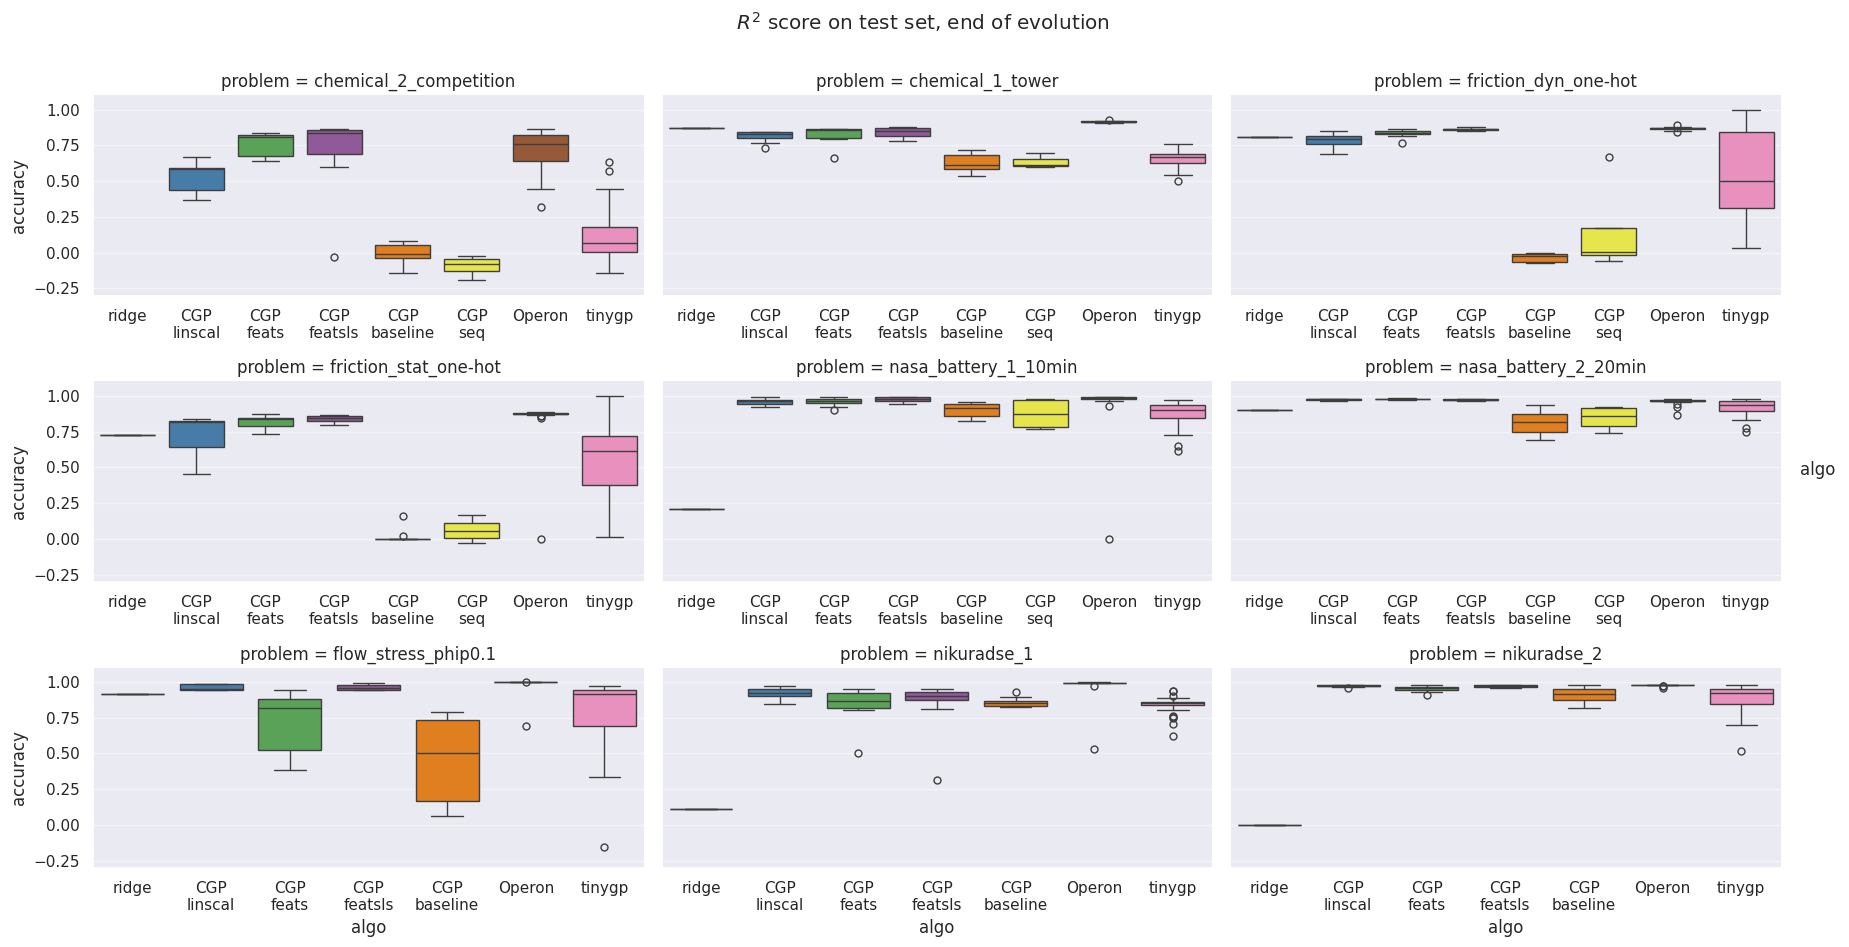

In [91]:
g = sns.catplot(x="algo", y="accuracy", hue="algo", data=final_df_and_baseline, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("$R^2$ score on test set, end of evolution", y=1.05)  # Add title above the plot
plt.ylim(-.3, 1.1)
plt.show()

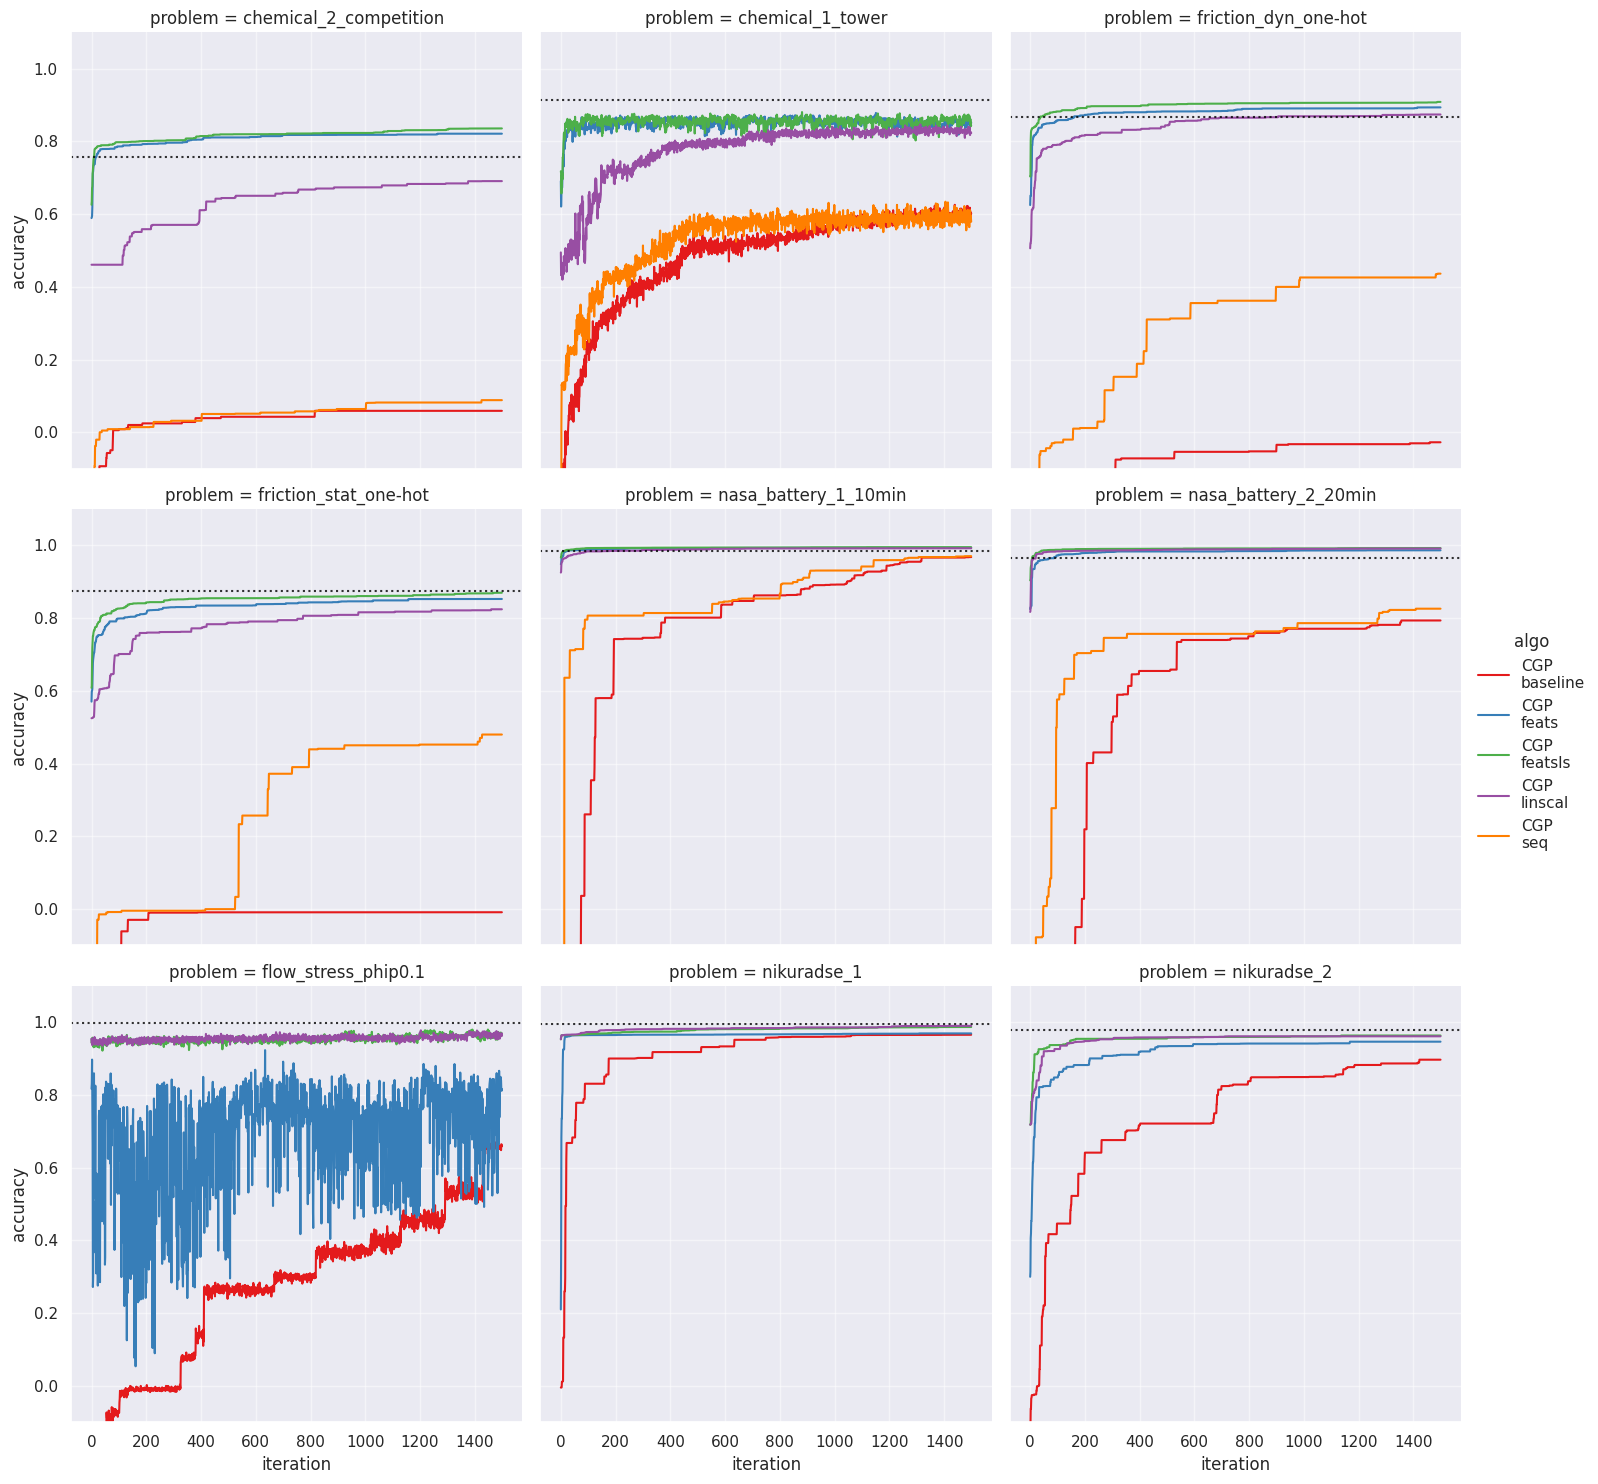

In [92]:
k = 50  # keep one point every 10 iterations
df_plot = (
    df[(df["when"] == "train") & (df["algo"] != "ridge")]
    .groupby(["problem", "algo", "iteration"], as_index=False)
    .accuracy.median()
)
operon_medians = (
    final_df_and_baseline
    .query("algo == 'Operon'")
    .groupby("problem")["accuracy"]
    .median()
)

g = sns.relplot(data=df_plot, x="iteration", y="accuracy", hue="algo", col_wrap=3,
            col="problem", errorbar=None, kind="line", palette="Set1", col_order=problems)
for ax in g.axes.flat:
    problem = ax.get_title().split(" = ")[-1]  # extract problem name from facet title

    if problem in operon_medians.index:
        ax.axhline(
            y=operon_medians.loc[problem],
            linestyle=":",
            color="black",
            linewidth=1.5,
            alpha=0.8,
        )
plt.ylim(-.1, 1.1)
plt.show()

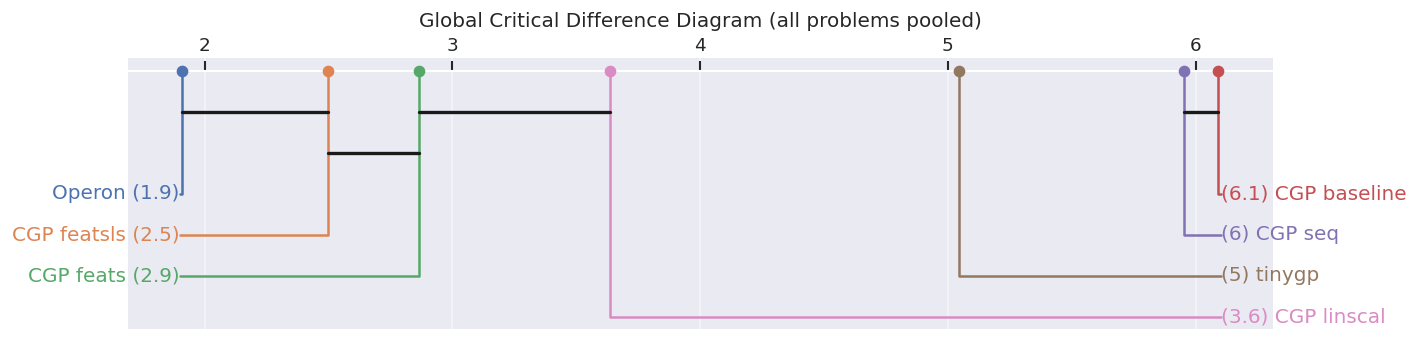

In [93]:
# -----------------------------
# 1. Copy + clean data
# -----------------------------
df = final_df_and_baseline.copy()

df = df[df["algo"] != "ridge"]
df = df[["problem", "seed", "algo", "accuracy"]].copy()

# clean strings
df["algo"] = (
    df["algo"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

# enforce numeric types (important)
df["seed"] = pd.to_numeric(df["seed"], errors="raise")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="raise")

# -----------------------------
# 2. Build global block (problem + seed)
# -----------------------------
df["block"] = df["problem"].astype(str) + "_seed_" + df["seed"].astype(str)

# -----------------------------
# 3. Pivot to wide format
# -----------------------------
df_wide = df.pivot(index="block", columns="algo", values="accuracy")

# optional: drop incomplete rows (safety)
df_wide = df_wide.dropna()

# -----------------------------
# 4. Compute average ranks (MAXIMIZATION)
# -----------------------------
avg_rank = df_wide.rank(axis=1, ascending=False).mean(axis=0)

# enforce consistent ordering
avg_rank = avg_rank.sort_values()

# -----------------------------
# 5. Posthoc Friedman
# -----------------------------
test_results = sp.posthoc_conover_friedman(df_wide)

# -----------------------------
# 6. Plot single CD diagram
# -----------------------------
plt.figure(figsize=(12, 3), dpi=120)
sp.critical_difference_diagram(avg_rank, test_results)

plt.title("Global Critical Difference Diagram (all problems pooled)")
plt.tight_layout()
plt.show()

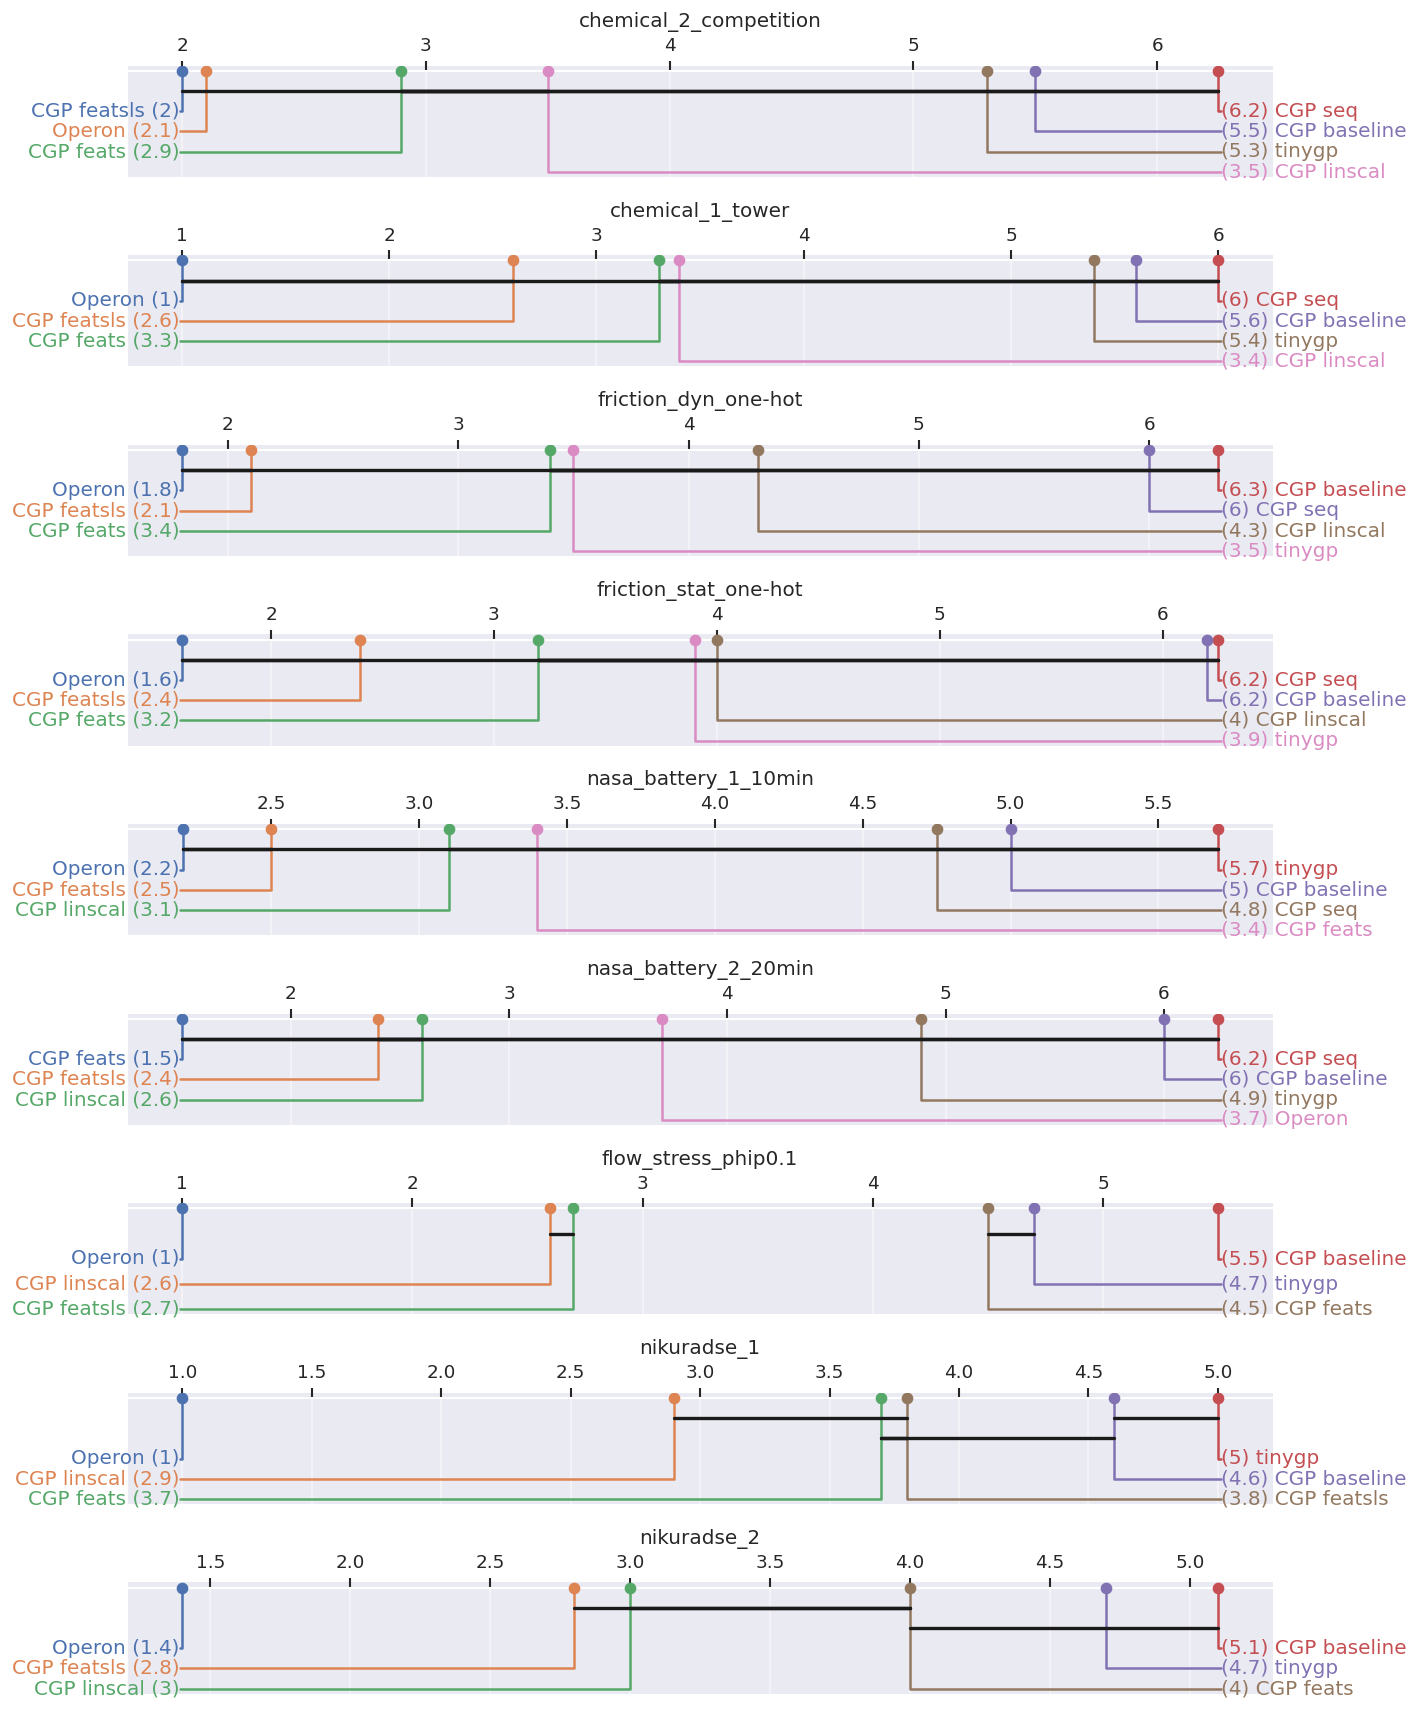

In [94]:
fig, axes = plt.subplots(
    nrows=len(problems),
    ncols=1,
    figsize=(12, 1.6 * len(problems)),
    dpi=120
)

if len(problems) == 1:
    axes = [axes]

for ax, problem in zip(axes, problems):
    df_tests = final_df_and_baseline[
        final_df_and_baseline["problem"] == problem
        ]

    df_tests = df_tests[df_tests["algo"] != "ridge"]
    df_tests = df_tests[df_tests["seed"] < 10][["seed", "algo", "accuracy"]]

    df_tests["algo"] = (
        df_tests["algo"]
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )

    df_wide = df_tests.pivot(index="seed", columns="algo", values="accuracy")

    # average ranks (this is correct for CD diagrams)
    rank = df_wide.rank(axis=1, ascending=False)
    avg_rank = rank.mean(axis=0)

    # posthoc
    test_results = sp.posthoc_conover_friedman(df_wide)

    # draw CD diagram
    plt.sca(ax)
    sp.critical_difference_diagram(
        avg_rank,
        test_results
    )

    ax.set_title(f"{problem}")

plt.tight_layout()
plt.show()

# Graph sizes

In [95]:
genome_sizes_df = pd.read_csv("genome_analysis.csv")
genome_sizes_df  #.head()

,problem,seed,algo,size
0,chemical_2_competition,0,linscal,7
1,friction_dyn_one-hot,0,linscal,10
2,friction_stat_one-hot,0,linscal,15
3,nasa_battery_1_10min,0,linscal,13
4,nasa_battery_2_20min,0,linscal,15
...,...,...,...,...
355,nasa_battery_2_20min,9,baseline,10
356,nikuradse_1,9,baseline,10
357,nikuradse_2,9,baseline,19
358,chemical_1_tower,9,baseline,7


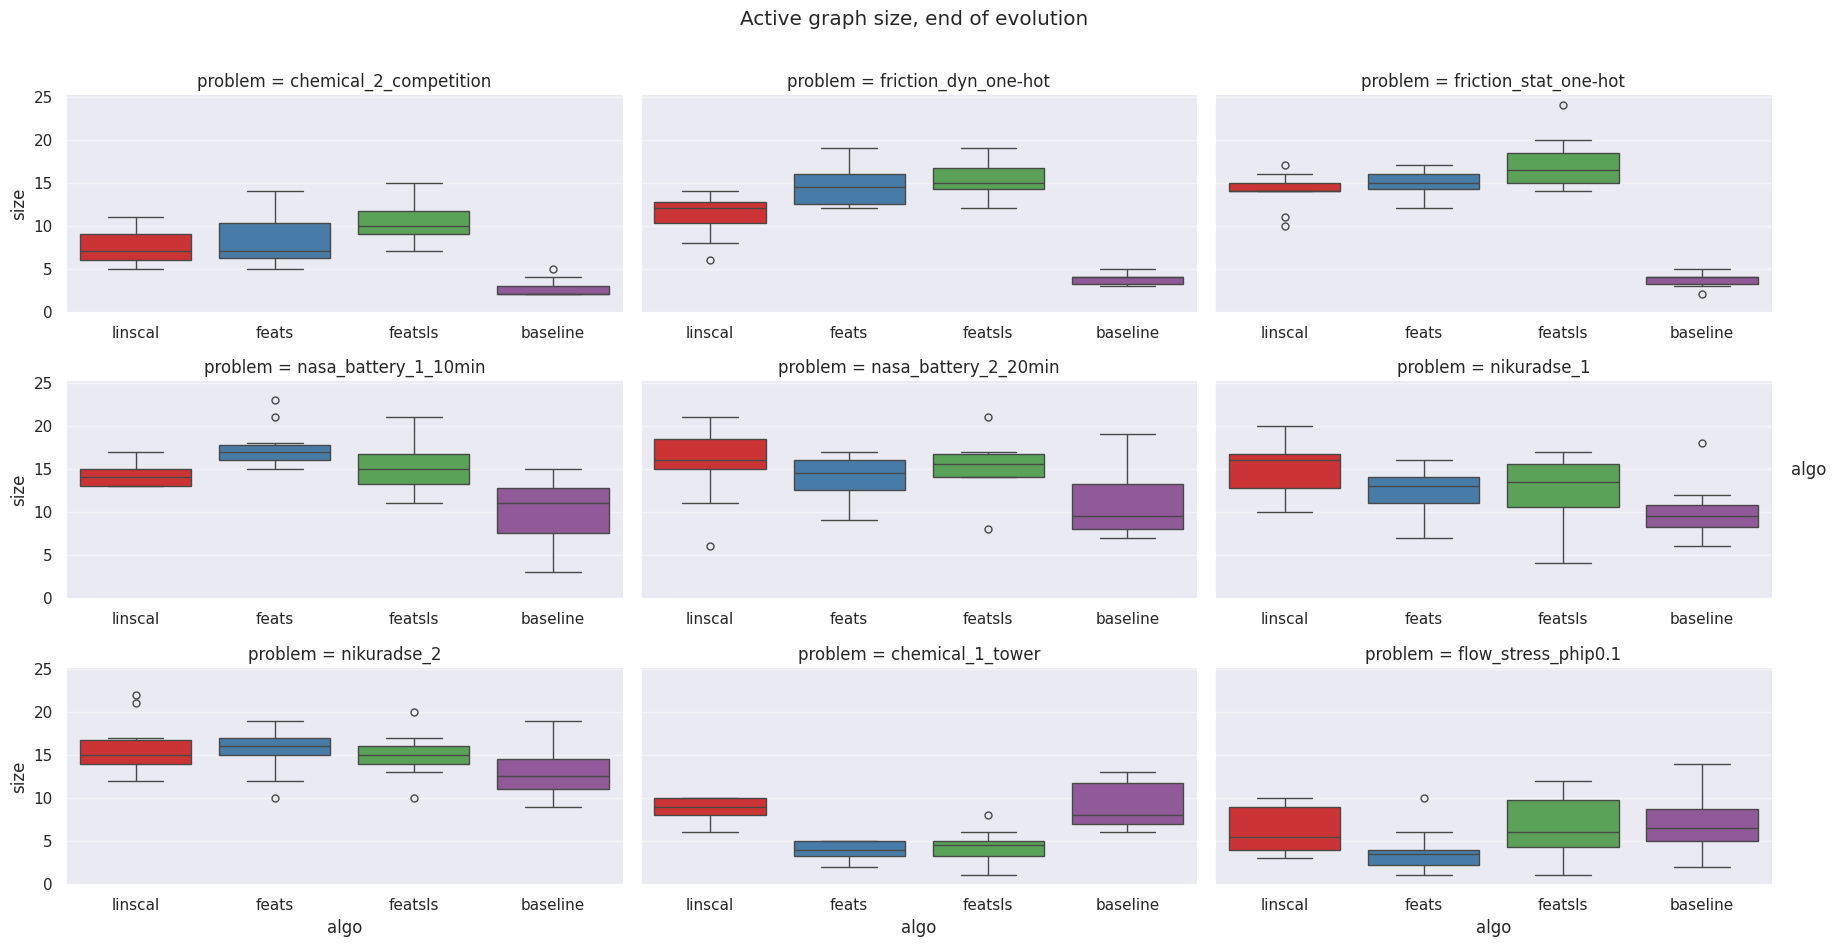

In [96]:
g = sns.catplot(x="algo", y="size", hue="algo", data=genome_sizes_df, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("Active graph size, end of evolution", y=1.05)  # Add title above the plot
# plt.ylim(-.3, 1.1)
plt.show()

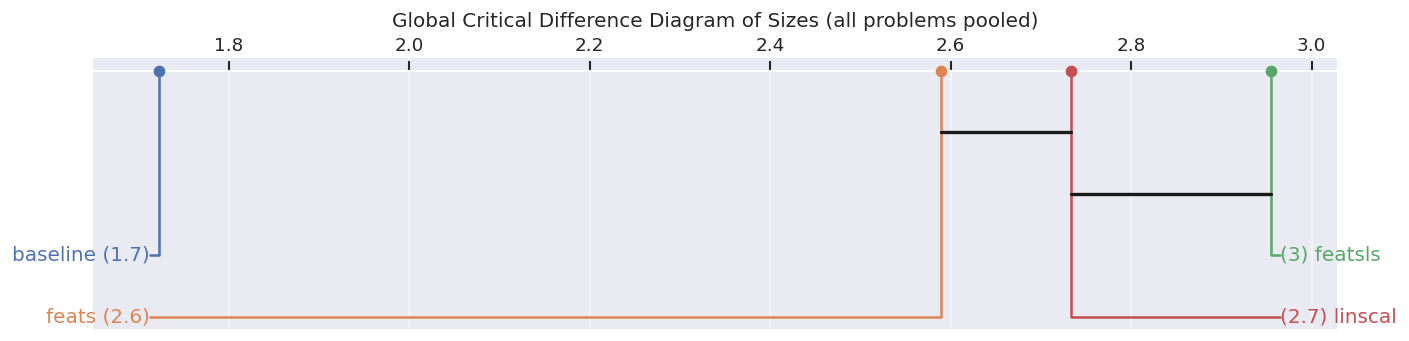

In [97]:
# -----------------------------
# 1. Copy + clean data
# -----------------------------
df = genome_sizes_df.copy()
df = df[["problem", "seed", "algo", "size"]].copy()

# clean strings
df["algo"] = (
    df["algo"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

# enforce numeric types (important)
df["seed"] = pd.to_numeric(df["seed"], errors="raise")
df["size"] = pd.to_numeric(df["size"], errors="raise")

# -----------------------------
# 2. Build global block (problem + seed)
# -----------------------------
df["block"] = df["problem"].astype(str) + "_seed_" + df["seed"].astype(str)

# -----------------------------
# 3. Pivot to wide format
# -----------------------------
df_wide = df.pivot(index="block", columns="algo", values="size")

# optional: drop incomplete rows (safety)
df_wide = df_wide.dropna()

# -----------------------------
# 4. Compute average ranks (MAXIMIZATION)
# -----------------------------
avg_rank = df_wide.rank(axis=1, ascending=True).mean(axis=0)

# enforce consistent ordering
avg_rank = avg_rank.sort_values()

# -----------------------------
# 5. Posthoc Friedman
# -----------------------------
test_results = sp.posthoc_conover_friedman(df_wide)

# -----------------------------
# 6. Plot single CD diagram
# -----------------------------
plt.figure(figsize=(12, 3), dpi=120)
sp.critical_difference_diagram(avg_rank, test_results)

plt.title("Global Critical Difference Diagram of Sizes (all problems pooled)")
plt.tight_layout()
plt.show()

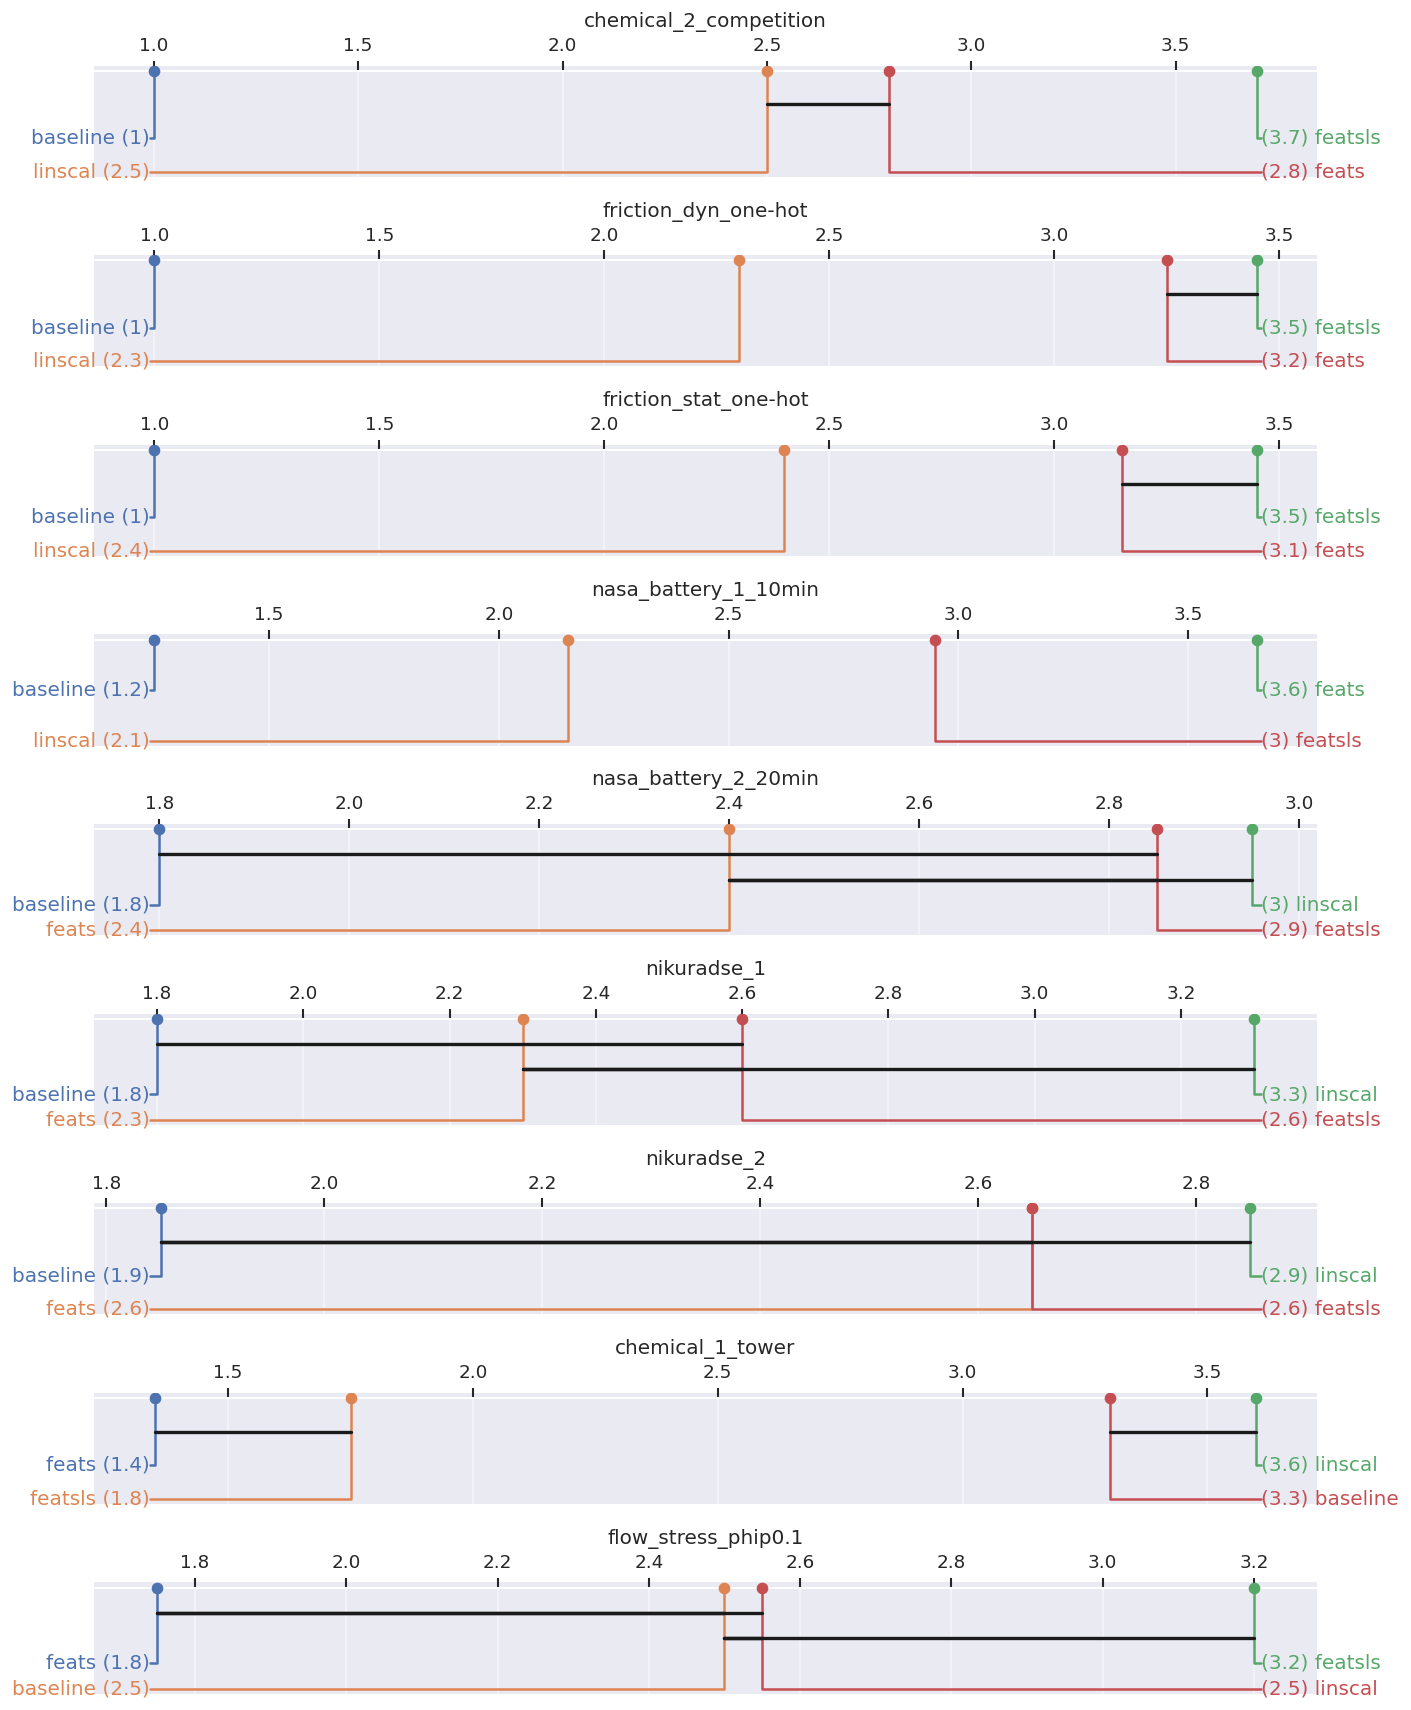

In [98]:
fig, axes = plt.subplots(
    nrows=len(genome_sizes_df["problem"].unique()),
    ncols=1,
    figsize=(12, 1.6 * len(genome_sizes_df["problem"].unique())),
    dpi=120
)

if len(genome_sizes_df["problem"].unique()) == 1:
    axes = [axes]

for ax, problem in zip(axes, genome_sizes_df["problem"].unique()):
    df_tests = genome_sizes_df[
        genome_sizes_df["problem"] == problem
        ]

    df_tests = df_tests[df_tests["seed"] < 10][["seed", "algo", "size"]]

    df_tests["algo"] = (
        df_tests["algo"]
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )

    df_wide = df_tests.pivot(index="seed", columns="algo", values="size")

    # average ranks (this is correct for CD diagrams)
    rank = df_wide.rank(axis=1, ascending=True)
    avg_rank = rank.mean(axis=0)

    # posthoc
    test_results = sp.posthoc_conover_friedman(df_wide)

    # draw CD diagram
    plt.sca(ax)
    sp.critical_difference_diagram(
        avg_rank,
        test_results
    )

    ax.set_title(f"{problem}")

plt.tight_layout()
plt.show()

# Sensitivity of features number

In [99]:
sensitivity_dfs = []
problem = "chemical_2_competition"
for n_feats in range(2, 58, 2):
    for seed in range(30):
        for extra in ['feats', 'featsls']:
            path = f"../results/sensitivity/CGP_{extra}_{problem}_{seed}_{n_feats}"
            if n_feats == 8:
                path = path.replace("/sensitivity", "").replace("_8", "")
            if os.path.exists(f"{path}.pickle"):
                tmp_df = pd.read_csv(f"{path}.csv")
                tmp_df["seed"] = seed
                tmp_df["problem"] = problem
                tmp_df["n_features"] = n_feats
                tmp_df["algo"] = f"CGP \n {extra}"
                tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                sensitivity_dfs.append(tmp_df)
sensitivity_df = pd.concat(sensitivity_dfs, ignore_index=True)
sensitivity_df["test_accuracy"] = sensitivity_df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
sensitivity_df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,n_features,algo,total_time
0,0,0.306892,0.000000,0.059002,0,chemical_2_competition,2,CGP \n feats,0
1,1,0.306892,1.660011,0.059002,0,chemical_2_competition,2,CGP \n feats,1
2,2,0.306892,0.858455,0.059002,0,chemical_2_competition,2,CGP \n feats,2
3,3,0.306892,0.914011,0.059002,0,chemical_2_competition,2,CGP \n feats,3
4,4,0.306892,0.949023,0.059002,0,chemical_2_competition,2,CGP \n feats,4


In [100]:
sensitivity_df1 = copy(sensitivity_df)
sensitivity_df2 = copy(sensitivity_df)
sensitivity_df1 = sensitivity_df1.rename(columns={"test_accuracy": "accuracy"})
sensitivity_df2 = sensitivity_df2.rename(columns={"max_fitness": "accuracy"})
sensitivity_df1 = sensitivity_df1.drop(columns=["max_fitness"])
sensitivity_df2 = sensitivity_df2.drop(columns=["test_accuracy"])
sensitivity_df1["when"] = "test"
sensitivity_df2["when"] = "train"
sensitivity_df = pd.concat([sensitivity_df1, sensitivity_df2], ignore_index=True)
sensitivity_df.head()

,iteration,time,accuracy,seed,problem,n_features,algo,total_time,when
0,0,0.000000,0.059002,0,chemical_2_competition,2,CGP \n feats,0,test
1,1,1.660011,0.059002,0,chemical_2_competition,2,CGP \n feats,1,test
2,2,0.858455,0.059002,0,chemical_2_competition,2,CGP \n feats,2,test
3,3,0.914011,0.059002,0,chemical_2_competition,2,CGP \n feats,3,test
4,4,0.949023,0.059002,0,chemical_2_competition,2,CGP \n feats,4,test


In [101]:
final_sensitivity_df = sensitivity_df[sensitivity_df["iteration"] == max(sensitivity_df["iteration"])].reset_index(
    drop=True)
final_sensitivity_df.head()

,iteration,time,accuracy,seed,problem,n_features,algo,total_time,when
0,1499,0.996661,0.622282,0,chemical_2_competition,2,CGP \n feats,1488,test
1,1499,0.963794,0.521470,0,chemical_2_competition,2,CGP \n featsls,1407,test
2,1499,1.070991,0.768297,1,chemical_2_competition,2,CGP \n feats,1691,test
3,1499,1.105551,0.757006,1,chemical_2_competition,2,CGP \n featsls,1708,test
4,1499,1.098661,0.656548,2,chemical_2_competition,2,CGP \n feats,1830,test


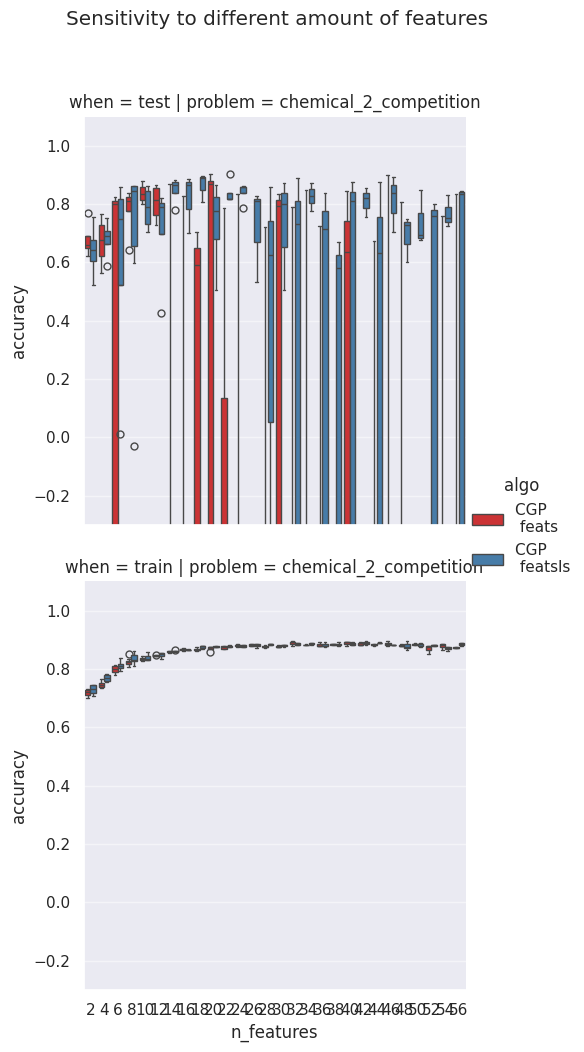

In [102]:
g = sns.catplot(x="n_features", y="accuracy", hue="algo", data=final_sensitivity_df, col="problem", row="when",
                kind="box", palette="Set1", sharex=True)  #height=3, aspect=2,
g.figure.suptitle("Sensitivity to different amount of features", y=1.05)  # Add title above the plot
plt.ylim(-.3, 1.1)
plt.show()

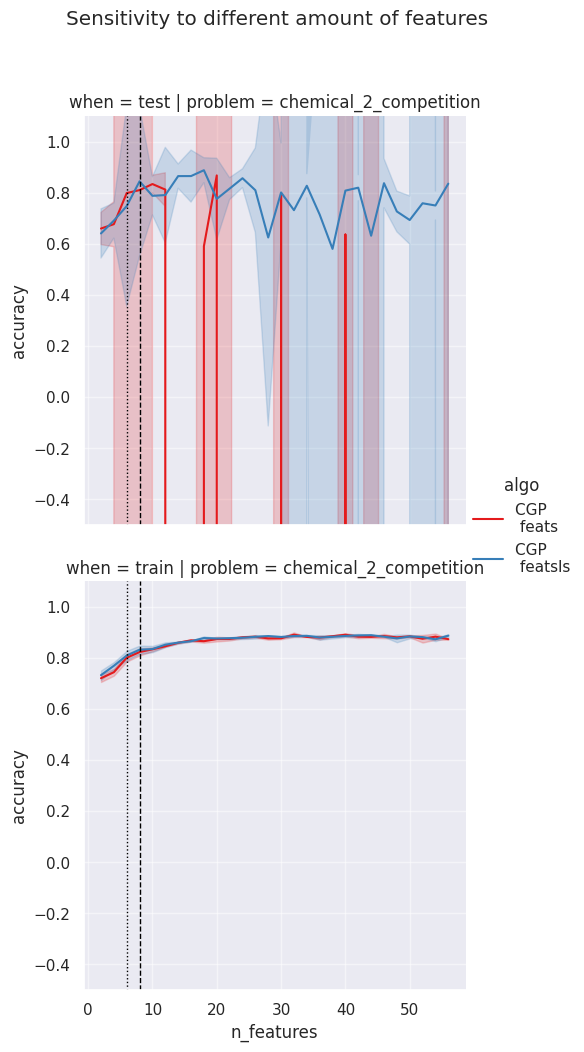

In [103]:
g = sns.relplot(
    data=final_sensitivity_df,
    x="n_features",
    y="accuracy",
    hue="algo",
    col="problem",
    row="when",
    kind="line",
    estimator="median",  # plot the mean
    errorbar="sd",  # shaded ±1 standard deviation
    # or errorbar=("ci", 95) for 95% confidence interval
    palette="Set1",
)
for ax in g.axes.flat:
    ax.axvline(x=6, linestyle=":", color="black", linewidth=1)
    ax.axvline(x=8, linestyle="--", color="black", linewidth=1)

g.figure.suptitle("Sensitivity to different amount of features", y=1.05)
g.set(ylim=(-0.5, 1.1))
plt.show()